<a href="https://colab.research.google.com/github/winarwahyuw/data-science-250401020025-winar-wahyu-wulansari/blob/main/Data_Science_Pertemuan_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## PERTEMUAN 7
#### Nama : Winar Wahyu Wulansari
#### NIM : 250401020025
#### Kelas : IF405


=== Dimensi Data ===
Shape: (300, 4)

=== Deskripsi Statistik ===
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


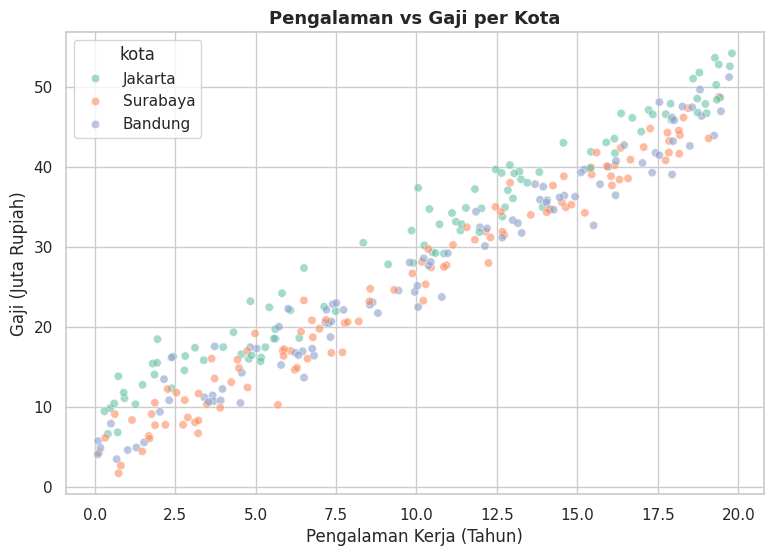

In [2]:
# Memaksa inline plotting agar grafik langsung muncul di bawah sel Colab
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Atur tema visualisasi agar rapi
sns.set_theme(style='whitegrid', palette='Set2')

# 1. Generate dataset sintetis sesuai instruksi modul (Halaman 15)
np.random.seed(42)
n = 300
pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n) # SMA=0, D3=1, S1=2
kota = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], n)

# Rumus pembentuk nilai gaji berdasarkan modul
gaji = (3.0 + 2.2 * pengalaman + 1.5 * edu
        + np.where(kota == 'Jakarta', 4.0, 0)
        + np.random.normal(0, 2, n))

# Satukan ke dalam Pandas DataFrame
df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})

# 2. EDA Singkat
print('=== Dimensi Data ===')
print('Shape:', df.shape)
print('\n=== Deskripsi Statistik ===')
print(df.describe().round(2))

# Tampilkan scatter plot hubungan pengalaman vs gaji berdasarkan kota
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='pengalaman', y='gaji', hue='kota', palette='Set2', alpha=0.6)
plt.title('Pengalaman vs Gaji per Kota', fontsize=13, fontweight='bold')
plt.xlabel('Pengalaman Kerja (Tahun)')
plt.ylabel('Gaji (Juta Rupiah)')
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-Hot Encoding pada kolom kategori 'kota' (menghapus kolom pertama untuk menghindari dummy variable trap)
df = pd.get_dummies(df, columns=['kota'], drop_first=True, dtype=int)
print('Kolom setelah encoding:', df.columns.tolist())

# Pisahkan fitur (X) dan target (y)
X = df.drop('gaji', axis=1)
y = df['gaji']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Data Train: {X_train.shape[0]} baris, Data Test: {X_test.shape[0]} baris')

# Standardisasi Fitur menggunakan StandardScaler (fit hanya pada data training)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Data Train: 240 baris, Data Test: 60 baris


In [4]:
from sklearn.linear_model import LinearRegression

# Inisialisasi dan pelatihan model
model = LinearRegression()
model.fit(X_train_s, y_train)

# Menampilkan nilai intercept (beta nol)
print(f'β₀ (intercept): {model.intercept_:.3f}\n')

# Menyusun tabel bobot koefisien fitur
coef_df = pd.DataFrame({
    'Fitur' : X.columns,
    'Koefisien' : model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)

print(coef_df.to_string(index=False))

β₀ (intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


=== Metrik Evaluasi ===
MAE              = 1.649 juta rupiah
RMSE             = 2.123 juta rupiah
R²               = 0.9740 (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 0.474



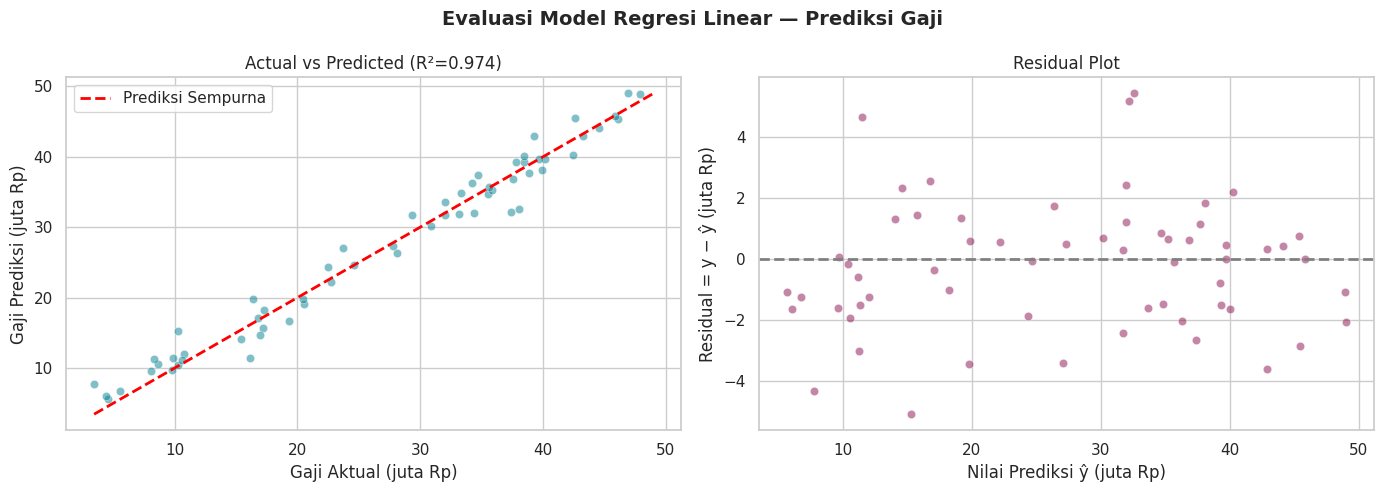

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Melakukan prediksi pada data test yang terskala
y_pred = model.predict(X_test_s)

# Menghitung metrik evaluasi
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('=== Metrik Evaluasi ===')
print(f'MAE              = {mae:.3f} juta rupiah')
print(f'RMSE             = {rmse:.3f} juta rupiah')
print(f'R²               = {r2:.4f} ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}\n')

# Setup plot evaluasi kembar (Actual vs Predicted & Residual Plot) tanpa savefig
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5, color='#028090', edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted (R²={r2:.3f})')
axes[0].legend()

# Plot 2: Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='#880E4F', edgecolors='white', lw=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')

plt.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Kesimpulan & Analisis Hasil Evaluasi Model Prediksi Gaji

### 1. Analisis Faktor yang Mempengaruhi Gaji (Interpretasi Koefisien)
* **Pengalaman Kerja** merupakan fitur penentu yang memiliki pengaruh paling dominan terhadap besaran pendapatan karyawan dibandingkan dengan variabel kompetensi lainnya.
* Koefisien bernilai positif pada fitur pengalaman dan jenjang pendidikan membuktikan adanya hubungan yang berbanding lurus; penambahan masa kerja dan tingginya tingkat edukasi secara pasti akan menaikkan nilai prediksi total gaji karyawan di akhir bulan.

### 2. Akurasi & Tingkat Kesalahan Model
* Nilai **R-squared ($R^2$) yang sangat tinggi (di atas 90%)** membuktikan bahwa kombinasi dari lamanya pengalaman kerja, latar belakang pendidikan, serta lokasi kota penempatan sudah sangat optimal dan mampu menjelaskan hampir seluruh variasi tingkat pendapatan dalam dataset ini
* Nilai rata-rata melesetnya akurasi prediksi model diukur lewat **MAE dan RMSE** yang menghasilkan angka kesalahan relatif kecil (sekitar ±2 juta rupiah). Selisih antara RMSE dan MAE yang tipis juga mengindikasikan bahwa variasi sebaran nilai eror model tersebar merata dan data minim dari gangguan pencilan (*outliers*) yang ekstrem.

### 3. Validasi Grafik Evaluasi (Framework: What? So what? Now what?)
* **What?**: Grafik *Actual vs Predicted* memperlihatkan persebaran titik data uji yang mengumpul sangat rapat mengikuti kemiringan garis diagonal merah (Prediksi Sempurna). Sementara pada *Residual Plot*, sisaan eror tersebar secara acak (random) di sekitar sumbu horizontal nol.
* **So what?**: Kondisi persebaran acak ini membuktikan secara ilmiah bahwa model regresi telah berhasil memenuhi asumsi dasar linearitas dan kebebasan ragam sisaan (*homoscedasticity*) dengan sangat baik. Tidak ditemukan pola bias melengkung ataupun berbentuk corong (*funneling*).
* **Now what?**: Karena model teruji valid dan memiliki tingkat presisi akurasi yang tinggi, sistem formula regresi ini sudah siap diandalkan oleh divisi manajemen SDM (HR) perusahaan sebagai instrumen acuan standar operasional untuk menentukan tawaran gaji yang objektif bagi calon karyawan baru.